In [12]:

import sys
!{sys.executable} -m pip install scipy numpy pandas matplotlib seaborn


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [25]:
import sys
sys.path.append("..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from src.estimator import (
    mle_bernoulli,
    mle_poisson,
    beta_posterior,
    log_likelihood_bernoulli,
    log_likelihood_poisson,
)
from scipy.stats import beta as beta_dist

pr = pd.read_csv("../data/clean/pull_requests_clean.csv")
iss = pd.read_csv("../data/clean/issues_clean.csv")


In [20]:

theta_hat = mle_bernoulli(pr['is_merged'])
k = int(pr['is_merged'].sum())          
m = int((~pr['is_merged']).sum())       
post = beta_posterior(k, m)
print(theta_hat, post)

0.8723076923076923 {'alpha': 1135, 'beta': 167, 'mode': 0.8723076923076923, 'mean': 0.8717357910906298}


Text(0, 0.5, 'log-likelihood')

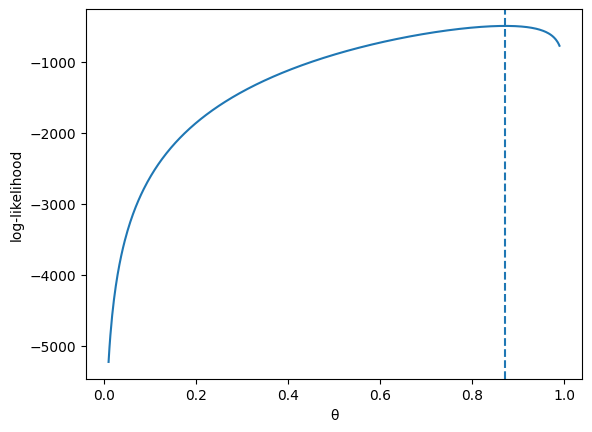

In [21]:
grip = np.linspace(0.01,0.99, 500)
plt.plot(grip, log_likelihood_bernoulli(grip, k,k+m))
plt.axvline(theta_hat, ls='--')
plt.xlabel("θ"); plt.ylabel("log-likelihood")


In [22]:
# Membuat grafik visualisasi kecenderungan parameter p
p_vals = np.linspace(0.01, 0.99, 100)
k = hasil_mle['k']
n = hasil_mle['n']

# Rumus Log-Likelihood Bernoulli: k*log(p) + (n-k)*log(1-p)
log_likelihood = k * np.log(p_vals) + (n - k) * np.log(1 - p_vals)

plt.figure(figsize=(8, 4))
plt.plot(p_vals, log_likelihood, label='Log-Likelihood Curve', color='teal')
plt.axvline(hasil_mle['p_hat'], color='red', linestyle='--', label=f"MLE (p_hat = {hasil_mle['p_hat']:.3f})")
plt.title('Bernoulli Log-Likelihood Curve for Django PR Merged Rate')
plt.xlabel('Parameter p (Probability of Merge)')
plt.ylabel('Log-Likelihood')
plt.legend()
plt.grid(True)
plt.show()

NameError: name 'hasil_mle' is not defined